<a href="https://colab.research.google.com/github/MariamKSharkawy/ML-projects/blob/ML_DL_projects/airplane_satisfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
d_train=pd.read_csv('/content/test.csv')
d_test=pd.read_csv('/content/train.csv')

In [ ]:
#print(data.columns.tolist())
new_train=d_train.drop(columns=['id','Unnamed: 0'],)
new_test=d_test.drop(columns=['id','Unnamed: 0'],)
#new_train.head(),new_test()
#print(data.columns.tolist())

In [ ]:
new_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    1039

In [ ]:
new_train['Arrival Delay in Minutes'].fillna(new_train['Arrival Delay in Minutes'].mode()[0],inplace=True)
new_test['Arrival Delay in Minutes'].fillna(new_test['Arrival Delay in Minutes'].mode()[0],inplace=True)

In [ ]:
new_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    1039

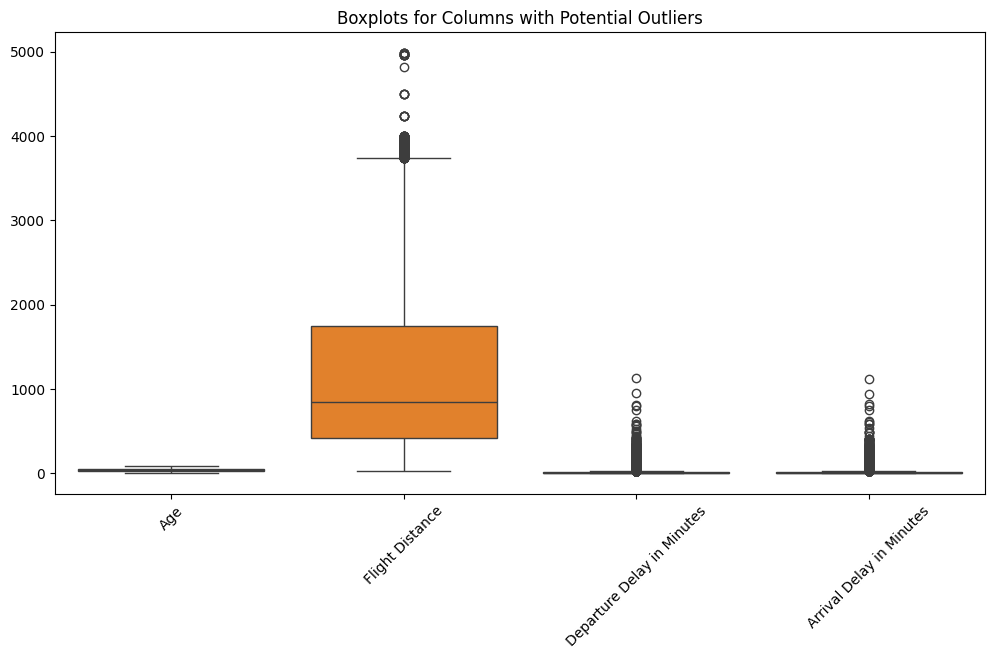

In [ ]:
col_to_plot=['Age','Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']
# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=new_train[col_to_plot])
plt.xticks(rotation=45)
plt.title("Boxplots for Columns with Potential Outliers")
plt.show()

In [ ]:
# Function to remove outliers using IQR
def remove_outliers(df, cols):
    # Loop through columns to remove outliers
    for col in cols:
        # Calculate the 25th and 75th percentiles (Q1 and Q3)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        # Calculate the IQR (Interquartile Range)
        IQR = Q3 - Q1

        # Define lower and upper bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Remove outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

# Columns to check for outliers
cols_to_check = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

# Remove outliers from both training and test data
cleaned_train = remove_outliers(new_train, cols_to_check)
cleaned_test = remove_outliers(new_test, cols_to_check)

# Show the cleaned data shapes
print(f"Original Train Data Length: {len(new_train)}")
print(f"Cleaned Train Data Length: {len(cleaned_train)}")
print(f"Original Test Data Length: {len(new_test)}")
print(f"Cleaned Test Data Length: {len(cleaned_test)}")


Original Train Data Length: 25976
Cleaned Train Data Length: 18875
Original Test Data Length: 103904
Cleaned Test Data Length: 75372


In [ ]:
x_train = pd.get_dummies(cleaned_train.drop(columns=['satisfaction']))
x_test = pd.get_dummies(cleaned_test.drop(columns=['satisfaction']))
y_train=cleaned_train['satisfaction']
y_test = cleaned_test['satisfaction']

In [ ]:
#one hot encoding
new_train=pd.get_dummies(new_train)
new_test=pd.get_dummies(new_test)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
new_train=sc.fit_transform(new_train)
new_test=sc.transform(new_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

classifier = SVC(kernel='linear', C=5)
classifier.fit(x_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = classifier.predict(x_test)

acc_test = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc_test * 100:.2f}%")


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
linear_regressor = LinearRegression()

# Train the model
linear_regressor.fit(x_train, y_train)

# Make predictions on the test data
y_pred = linear_regressor.predict(x_test)

# Calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Calculate R-squared (coefficient of determination)
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

# Optional: Check the performance of the model on training data
y_train_pred = linear_regressor.predict(x_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Training Mean Squared Error: {train_mse:.2f}")
print(f"Training R-squared: {train_r2:.2f}")


In [ ]:
new_train=pd.get_dummies(new_train)
new_test=pd.get_dummies(new_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict on the test data
y_pred = rf_classifier.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")



Accuracy: 0.95


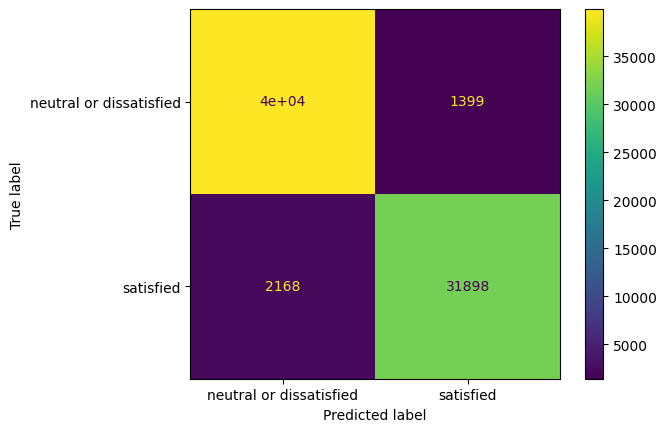

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dt_classifier.classes_)
disp.plot()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize the Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dt_classifier.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt_classifier.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.93


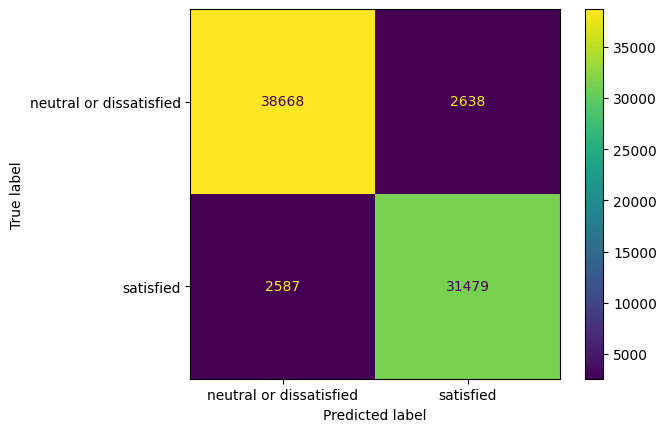

In [ ]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dt_classifier.classes_)
disp.plot()
plt.show()